# RLSSM Basic Tutorial

This tutorial introduces **Reinforcement Learning Sequential Sampling Models (RLSSM)** in HSSM. An RLSSM combines:

1. A **learning process** that updates beliefs from feedback (e.g. Rescorla–Wagner).
2. A **decision process** (sequential sampling model, SSM) that generates choices and RTs.

We simulate data with [`ssm-simulators`](https://github.com/lnccbrown/ssm-simulators) (`ssms.rl`), bridge the model into HSSM with `RLSSMConfig.from_ssms_model`, fit a hierarchical model, and run posterior predictive checks with `mode="ppc"`.

**Next tutorials:** [Advanced](rlssm_advanced.ipynb) · [Restless learner](rlssm_restless_learner.ipynb) · [HSSM custom models](rlssm_hssm_custom_models.ipynb)

## Setup

In [1]:

import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)


def make_participant_theta(group_theta, sds, bounds, n, rng):
    """Sample participant-level parameters around group means."""
    theta_arrays = {}
    for name, mean in group_theta.items():
        lo, hi = bounds[name]
        theta_arrays[name] = np.clip(rng.normal(mean, sds[name], size=n), lo, hi)
    true_df = pd.DataFrame(theta_arrays)
    true_df.index.name = "participant_id"
    return theta_arrays, true_df


PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": {"name": "Normal", "mu": 0, "sigma": 0.1},
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lo, hi, mu, sigma):
    """Build a truncated-normal group mean with participant random effects."""
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior("TruncatedNormal", lower=lo, upper=hi, mu=mu, sigma=sigma),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )


def per_participant_posterior_means(idata, list_params):
  post = idata.posterior
  out = {}
  for name in list_params:
      inter = post[f"{name}_Intercept"]
      re = post[f"{name}_1|participant_id"]
      re_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
      per_p = (inter + re).mean(("chain", "draw"))
      ids = [int(v) for v in re[re_dim].values]
      out[name] = pd.Series(np.asarray(per_p.values), index=ids).sort_index()
  return pd.DataFrame(out)


def plot_group_recovery(idata, list_params, group_theta, title):
    names = [f"{n}_Intercept" for n in list_params]
    summ = az.summary(idata, var_names=names, kind="stats")
    summ.index = list_params
    summ["true"] = [group_theta[n] for n in list_params]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(list_params))
    ax.errorbar(
        summ["mean"],
        y,
        xerr=[summ["mean"] - summ["hdi_3%"], summ["hdi_97%"] - summ["mean"]],
        fmt="o",
        capsize=4,
        label="posterior (intercept)",
    )
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5, label="true group mean")
    ax.set_yticks(y)
    ax.set_yticklabels(list_params)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summ


def run_ppc(ssms_config, observed_data, ppc_theta, random_state=0):
    """Posterior predictive simulation conditioned on observed learning history."""
    return rl.Simulator(ssms_config).simulate(
        theta=ppc_theta,
        mode="ppc",
        observed_data=observed_data,
        random_state=random_state,
    )


def plot_rt_choice_ppc(observed, ppc, title="Posterior predictive check"):
    obs_rt = observed["rt"].to_numpy()
    ppc_rt = ppc["rt"].to_numpy()
    obs_rt = obs_rt[np.isfinite(obs_rt) & (obs_rt > 0)]
    ppc_rt = ppc_rt[np.isfinite(ppc_rt) & (ppc_rt > 0)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    if len(obs_rt) and len(ppc_rt):
        axes[0].hist(obs_rt, bins=25, density=True, alpha=0.5, label="observed")
        axes[0].hist(ppc_rt, bins=25, density=True, alpha=0.5, label="ppc")
    axes[0].set_title("RT distribution")
    axes[0].legend()
    obs_resp = observed["response"]
    ppc_resp = ppc["response"]
    valid = obs_resp > -900
    obs_choice = obs_resp[valid].value_counts(normalize=True).sort_index()
    valid_ppc = ppc_resp > -900
    ppc_choice = ppc_resp[valid_ppc].value_counts(normalize=True).sort_index()
    labels = sorted(set(obs_choice.index) | set(ppc_choice.index))
    x = np.arange(len(labels))
    axes[1].bar(x - 0.2, [obs_choice.get(c, 0) for c in labels], width=0.4, label="observed")
    axes[1].bar(x + 0.2, [ppc_choice.get(c, 0) for c in labels], width=0.4, label="ppc")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_title("Response proportions")
    axes[1].legend()
    fig.suptitle(title)
    plt.show()


Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


## Simulation scale

We use smaller settings so the notebook can be re-executed in documentation builds. Set environment variable `FULL_RUN=1` before building for richer outputs.

In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"
N_PARTICIPANTS = 12 if FULL_RUN else 4
N_TRIALS = 200 if FULL_RUN else 80
N_CHAINS = 2
N_DRAWS = 150 if FULL_RUN else 80
N_TUNE = 150 if FULL_RUN else 80
RANDOM_SEED = 20260704


## Step 1 — Explore the `2AB_RW_Angle` preset

`ssms.rl` ships named presets that bundle a task environment, learning rule, and decision process. `2AB_RW_Angle` is a two-armed bandit with Rescorla–Wagner learning and an angle (collapsing-bound) DDM.

In [3]:
ssms_config = rl.preset.get("2AB_RW_Angle")
print(rl.preset.info('2AB_RW_Angle'))
assembled = ssms_config.assemble(backend="jax")
print("computed_params:", assembled.computed_params)
print("context_fields:", assembled.context_fields)
assert assembled.gradient == "available", "HSSM inference needs JAX gradients"

Preset: 2AB_RW_Angle
Description: Two-armed bandit with a Rescorla-Wagner delta-rule learner and an angle decision process.
Task: two-armed Bernoulli bandit
Learning process: RescorlaWagnerDeltaRule
Decision process: angle
Required parameters: rl_alpha, scaler, a, z, t, theta
Default parameters: rl_alpha=0.2, scaler=2, a=1, z=0.5, t=0.001, theta=0
Response labels: (-1, 1)
Response to choice: {-1: 0, 1: 1}
Context fields: ['feedback']
Learning backend: jax
Gradient support: available
HSSM participant contract: yes
computed_params: ['v']
context_fields: ['feedback']


## Step 2 — Simulate hierarchical data

Pass **participant-wise** parameter arrays to `Simulator.simulate`. Each row of the returned DataFrame is one trial with `participant_id`, `trial_id`, `rt`, `response`, and context fields such as `feedback`.

In [4]:
GROUP_THETA = {
    "rl_alpha": 0.35, "scaler": 2.2, "a": 1.2, "z": 0.5, "t": 0.25, "theta": 0.35,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0), "scaler": (0.1, 5.0), "a": (0.3, 2.5),
    "z": (0.1, 0.9), "t": (0.05, 1.0), "theta": (0.0, 1.2),
}
SDS = {k: 0.08 for k in GROUP_THETA}
LIST_PARAMS = list(GROUP_THETA)
rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, true_params = make_participant_theta(
    GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng
)
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()
print(data.head())
print("shape:", data.shape)

   participant_id  trial_id        rt  response  feedback
0               0         0  1.053084        -1       1.0
1               0         1  1.626695        -1       1.0
2               0         2  1.174472        -1       1.0
3               0         3  0.471065        -1       1.0
4               0         4  1.028647        -1       1.0
shape: (2400, 5)


## Step 3 — Bridge to HSSM with `from_ssms_model`

`RLSSMConfig` holds **model metadata**: parameter names, bounds, which fields come from data (`extra_fields`), and which SSM parameters are **computed** by the learning rule (e.g. drift `v`). Edit this config (or the underlying `ssms` model) when you change the model structure.

In [5]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)
print("list_params :", model_config.list_params)
print("extra_fields:", model_config.extra_fields)
print("computed    :", set(model_config.ssm_logp_func.computed))
assert "v" in model_config.ssm_logp_func.computed
assert "v" not in model_config.list_params or model_config.list_params.count("v") == 0

list_params : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
extra_fields: ['feedback']
computed    : {'v'}


## Step 4 — Build and inspect `hssm.RLSSM`

`RLSSM` is the user-facing class. Pass your trial-level `data` and `model_config`. Use `hssm.Param` objects to specify hierarchical priors.

In [6]:
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.30, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.0, 0.8),
        hierarchical_param("a", 0.3, 2.5, 1.1, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
        hierarchical_param("theta", 0.0, 1.2, 0.35, 0.15),
    ],
)
print("Participants:", model.n_participants, "| Trials:", model.n_trials)
print("Free parameters:", list(model.params.keys()))
assert "rl_alpha" in model.params
assert "v" not in model.params  # v is computed by the learning rule

You supplied a model '2AB_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


User prior for '1|participant_id' on parameter 'rl_alpha' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'rl_alpha ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'scaler' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'scaler ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'a' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'a ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'z' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'z ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


...

User prior for '1|participant_id' on parameter 't' has a non-trivial `mu`, and the formula also includes a common `Intercept` for 't'. The data only constrains the sum `Intercept + mu`; the two are non-identifiable individually and the posterior will have a ridge along the anti-diagonal. Set `mu=0` on the group term so the common `Intercept` owns the location, or drop the common intercept from the formula (e.g. `t ~ 0 + (1|participant_id)`).


User prior for '1|participant_id' on parameter 'theta' has a non-trivial `mu`, and the formula also includes a common `Intercept` for 'theta'. The data only constrains the sum `Intercept + mu`; the two are non-identifiable individually and the posterior will have a ridge along the anti-diagonal. Set `mu=0` on the group term so the common `Intercept` owns the location, or drop the common intercept from the formula (e.g. `theta ~ 0 + (1|participant_id)`).


The PyMC graph contains free random variables that do not influence the likelihood: 'rl_alpha_1|participant_id_mu', 'scaler_1|participant_id_mu', 'a_1|participant_id_mu', 'z_1|participant_id_mu', 't_1|participant_id_mu', 'theta_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


Participants: 12 | Trials: 200
Free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


### Inspect the built statistical model

After construction, `model.model` is the Bambi model and `model.pymc_model` is the underlying PyMC graph — useful for debugging priors and the likelihood wiring.

In [7]:
print(model.model)
print("---")
print(model.pymc_model)

       Formula: c(rt, response) ~ 1 + (1|participant_id)
                scaler ~ 1 + (1|participant_id)
                a ~ 1 + (1|participant_id)
                z ~ 1 + (1|participant_id)
                t ~ 1 + (1|participant_id)
                theta ~ 1 + (1|participant_id)
        Family: SSM Family
          Link: rl_alpha = identity
                scaler = identity
                a = identity
                z = identity
                t = identity
                theta = identity
  Observations: 2400
        Priors: 
    target = rl_alpha
        Common-level effects
            Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.30000001192092896,
                sigma: 0.15000000596046448)
        
        
        Group-level effects
            1|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.10000000149011612), sigma:
                HalfNormal(sigma: 0.5))

    target = scaler
        Common-level effects
            scaler_Intercept ~ Tr

## Step 5 — Sample the posterior

In [8]:
idata = model.sample(
    draws=N_DRAWS,
    tune=N_TUNE,
    chains=N_CHAINS,
    cores=N_CHAINS,
    sampler="numpyro",
    target_accept=0.9,
    random_seed=RANDOM_SEED,
)
idata

Using default initvals. 



  0%|          | 0/300 [00:00<?, ?it/s]

warmup:   0%|          | 1/300 [00:01<07:34,  1.52s/it, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:  11%|█▏        | 34/300 [00:01<00:09, 28.93it/s, 1 steps of size 5.99e-35. acc. prob=0.00]

warmup:  18%|█▊        | 54/300 [00:01<00:05, 45.94it/s, 1 steps of size 1.18e-38. acc. prob=0.00]

...

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 1/300 [00:00<00:31,  9.59it/s]

 58%|█████▊    | 173/300 [00:00<00:00, 996.84it/s]

100%|██████████| 300/300 [00:00<00:00, 1063.10it/s]

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

## Step 6 — Diagnostics and group-level recovery

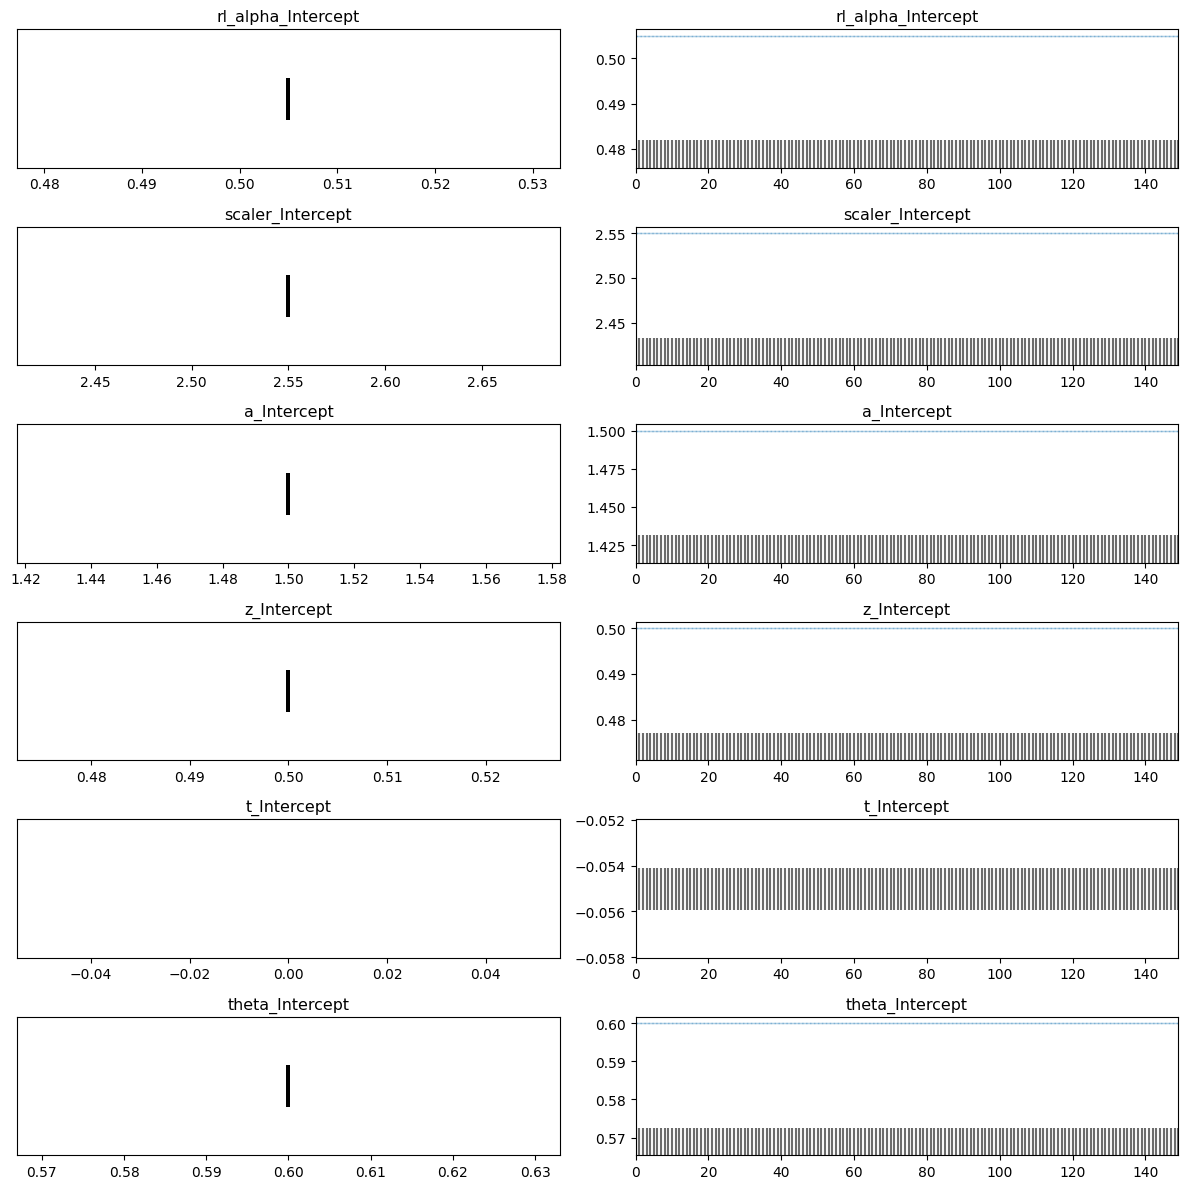

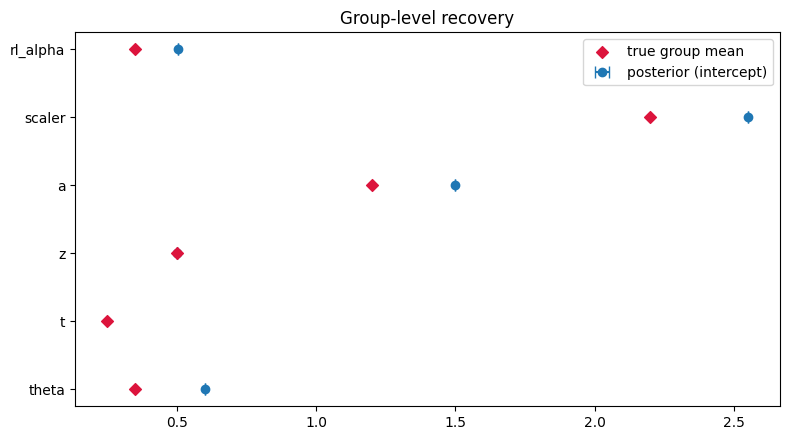

,mean,sd,hdi_3%,hdi_97%,true
rl_alpha,0.505,0.0,0.505,0.505,0.35
scaler,2.550,0.0,2.550,2.550,2.20
a,1.500,0.0,1.500,1.500,1.20
z,0.500,0.0,0.500,0.500,0.50
t,NaN,NaN,NaN,NaN,0.25
theta,0.600,0.0,0.600,0.600,0.35


In [9]:
az.plot_trace(idata, var_names=[f"{p}_Intercept" for p in LIST_PARAMS], compact=True)
plt.tight_layout()
plt.show()
summ = plot_group_recovery(idata, LIST_PARAMS, GROUP_THETA, "Group-level recovery")
summ

## Step 7 — Posterior predictive checks with `mode="ppc"`

Generic posterior predictive sampling does not condition learning state on the observed reward history. `ssms.rl` `mode="ppc"` updates learning from observed responses and feedback, then resimulates RT and choice — appropriate for RLSSM model checking.

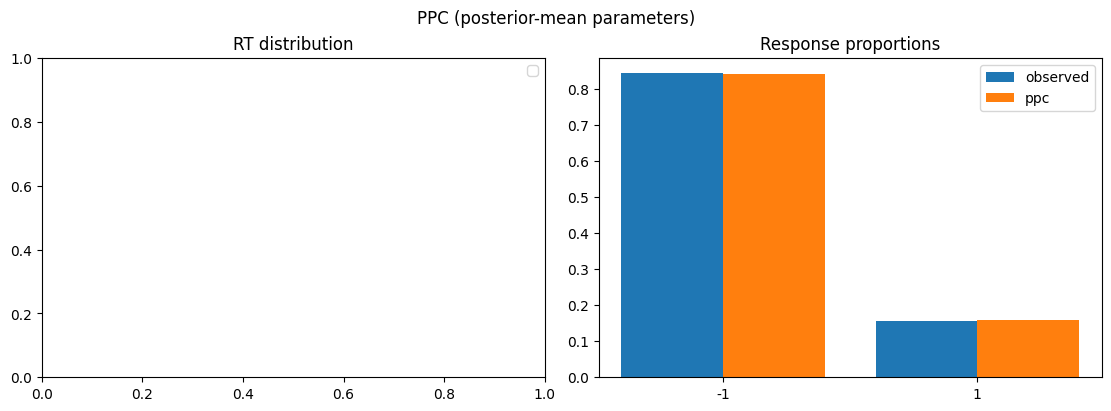

In [10]:
try:
    rec = per_participant_posterior_means(idata, LIST_PARAMS)
    ppc_theta = {n: rec[n].reindex(range(N_PARTICIPANTS)).to_numpy() for n in LIST_PARAMS}
except Exception as exc:
    print("Using group means for PPC:", exc)
    ppc_theta = {n: np.full(N_PARTICIPANTS, GROUP_THETA[n]) for n in LIST_PARAMS}
ppc_data = run_ppc(ssms_config, data, ppc_theta, random_state=RANDOM_SEED + 1)
plot_rt_choice_ppc(data, ppc_data, "PPC (posterior-mean parameters)")

## Summary

You simulated an RLSSM with `ssms.rl`, bridged it with `from_ssms_model`, fit `hssm.RLSSM`, and checked fit with `mode="ppc"`.

HSSM also supports **choice-only** reinforcement learning models (without RT); those are documented separately once fully validated with the current HSSM release.